####  학습목표
- 시각화 패키지 matplotlib , seaborn, folium
- 서브 패키지   pyplot , plotly
- 웹 시각화     streamlit

In [14]:
import numpy  as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import json   

# warning 제거
import warnings
warnings.filterwarnings('ignore')

# version check 
print('numpy  version - ' , np.__version__)
print('pandas version - ' , pd.__version__)

# 데이터 정보 출력 함수 
def aryInfo(ary) : 
    print('type - ' , type(ary)) 
    print('shape - ' , ary.shape)
    print('ndim  - ' , ary.ndim)
    print('dtype - ' , ary.dtype)
    print()
    print('data  -')
    print(ary) 
    
def seriesInfo(s) :
    print('type   - ' , type(s)) 
    print('index  - ' , s.index)
    print('values - ' , s.values)
    print('dtype  - ' , s.dtype)
    print()
    print('data   - ')
    print(s) 

def frmInfo(frm) :
    print('type    - ' , type(frm))
    print('shape   - ' , frm.shape)
    print('ndim    - ' , frm.ndim)
    print('row idx - ' , frm.index , type(frm.index))
    print('col idx - ' , frm.columns , type(frm.columns))
    print('values  - ' , type(frm.values))
    print(frm.values)
    print('data - ') 
    print(frm)


numpy  version -  2.1.3
pandas version -  2.2.3


In [15]:
%matplotlib inline

# 한글 폰트 문제 해결
import platform
from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~') 


# 차트 축 <- 음수 부호 지원
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False    

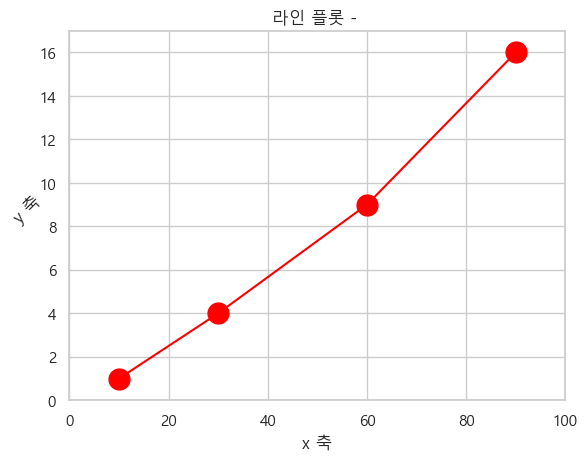

In [23]:
plt.figure()

# plt.plot([1,2,3,4,5,6,7,8,9])
# plt.plot([1,4,9,5,6,7,2,7,9])

plt.plot([10, 30, 60, 90],
         [1, 4, 9, 16], 
         color = 'red',
         marker = 'o',
         ms = 15)

plt.title('라인 플롯 - ')
plt.xlabel('x 축')
plt.ylabel('y 축' , rotation=45)

plt.xlim(0, 100)
plt.ylim(0, 17)

plt.show()
plt.close()

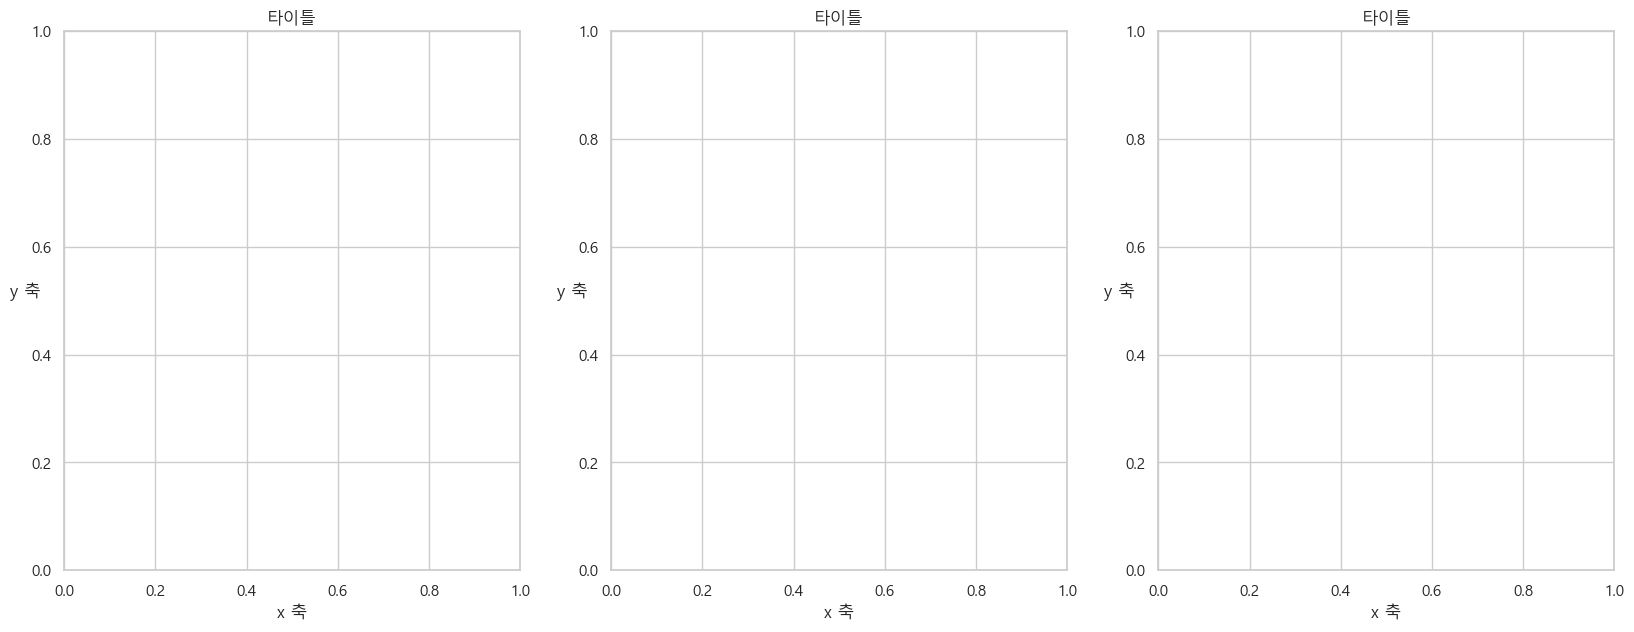

In [33]:
# 서브플롯을 이용해서 한 화면에 여러개의 플롯을 그릴 수 있다.

fig = plt.figure(figsize = (20, 7))

area01 = fig.add_subplot(1, 3, 1)
area01.set_title('타이틀')
area01.set_xlabel('x 축')
area01.set_ylabel('y 축' , rotation=0)

area02 = fig.add_subplot(1, 3, 2)
area02.set_title('타이틀')
area02.set_xlabel('x 축')
area02.set_ylabel('y 축' , rotation=0)

area03 = fig.add_subplot(1, 3, 3)
area03.set_title('타이틀')
area03.set_xlabel('x 축')
area03.set_ylabel('y 축' , rotation=0)

plt.show()
plt.close()

In [34]:
print('bar char : x축이 범주형타입(category)') 

titanicFrm = sns.load_dataset('titanic') 
titanicFrm.info()

bar char : x축이 범주형타입(category)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [42]:
# Q
# 선실등급별 생존자 합을 시각화 한다면?
# titanicFrm.groupby('pclass').groups
# titanicFrm.groupby('pclass')['survived'].sum().index
# titanicFrm.groupby('pclass')['survived'].sum().values

array([136,  87, 119])

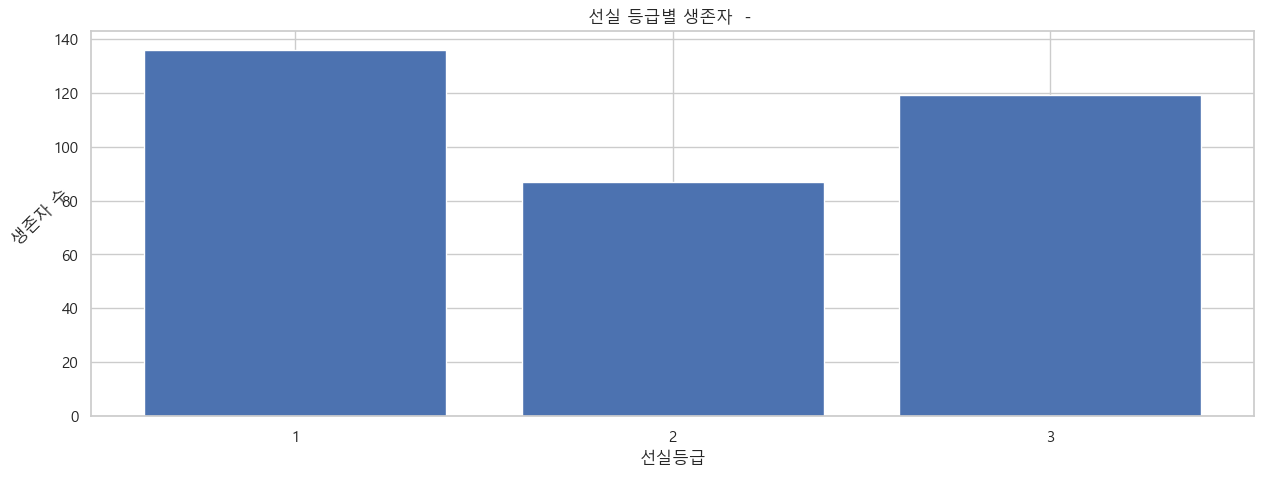

In [46]:
plt.figure(figsize = (15,5))

plt.bar(titanicFrm.groupby('pclass')['survived'].sum().index, 
        titanicFrm.groupby('pclass')['survived'].sum().values)

plt.xticks(titanicFrm.groupby('pclass')['survived'].sum().index)

plt.title('선실 등급별 생존자  - ')
plt.xlabel('선실등급')
plt.ylabel('생존자 수' , rotation=45)

plt.show()
plt.close()

In [ ]:
# 간단한 시각화를 위해서 더미 데이터 세트를 만들어 보자 
# 로그인 로그 데이터( timestamp, user, ip, status, delay_ms )

In [50]:
# timestamp : pd.date_range('2025-11-06', periods=100, freq='H')
# user : np.random.choice(['admin', 'superAdmin', 'root', 'guest', 'analyst'], 100)
# ip : np.random.choice(['192.168.0.1', '192.168.0.3', '192.168.0.5', '192.168.0.7', '192.168.0.9'], 100)
# status : np.random.choice(['success', 'fail'], 100, p=[0.6, 0.4])
# delay_ms : np.random.randint(20, 800, 100)

array(['fail', 'success', 'success', 'success', 'success', 'fail', 'fail',
       'success', 'fail', 'success', 'fail', 'success', 'success',
       'success', 'success', 'success', 'success', 'success', 'success',
       'fail', 'success', 'success', 'fail', 'fail', 'success', 'success',
       'fail', 'success', 'fail', 'fail', 'success', 'success', 'fail',
       'success', 'success', 'fail', 'fail', 'fail', 'fail', 'fail',
       'fail', 'fail', 'fail', 'success', 'success', 'fail', 'fail',
       'fail', 'fail', 'fail', 'success', 'success', 'success', 'success',
       'success', 'fail', 'success', 'fail', 'success', 'fail', 'success',
       'success', 'success', 'fail', 'success', 'fail', 'success',
       'success', 'fail', 'success', 'success', 'success', 'success',
       'fail', 'success', 'success', 'success', 'fail', 'success',
       'success', 'fail', 'fail', 'success', 'success', 'success',
       'success', 'success', 'success', 'success', 'success', 'fail',
       'f

In [52]:
frm = pd.DataFrame({
    "timestamp" : pd.date_range('2025-11-06', periods=100, freq='H'),
    "user"      : np.random.choice(['admin', 'superAdmin', 'root', 'guest', 'analyst'], 100),
    "ip"        : np.random.choice(['192.168.0.1', '192.168.0.3', '192.168.0.5', '192.168.0.7', '192.168.0.9'], 100),
    "status"    : np.random.choice(['success', 'fail'], 100, p=[0.6, 0.4]),
    "delay_ms"  : np.random.randint(20, 800, 100)
})
frm.head()

,timestamp,user,ip,status,delay_ms
0,2025-11-06 00:00:00,guest,192.168.0.7,fail,465
1,2025-11-06 01:00:00,root,192.168.0.7,success,369
2,2025-11-06 02:00:00,analyst,192.168.0.3,success,626
3,2025-11-06 03:00:00,guest,192.168.0.3,fail,683
4,2025-11-06 04:00:00,analyst,192.168.0.7,success,156


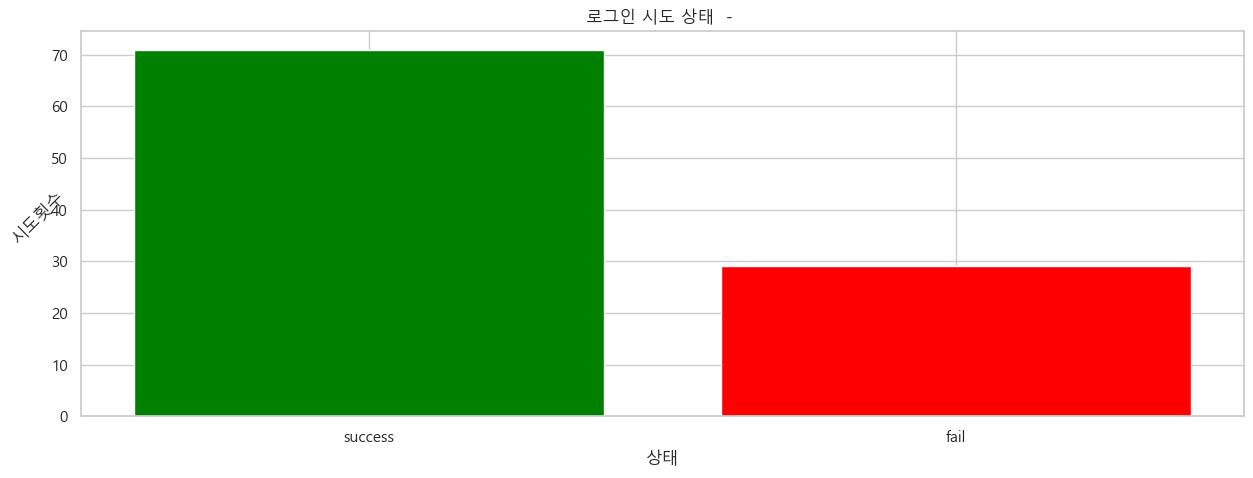

In [65]:
# frm.info()
# Q
# 로그인 시도 상태별 횟수를 bar plot 이용하여 시각화 

# frm['status'].value_counts()
# frm.groupby('status')['status'].count()

plt.figure(figsize = (15,5))

plt.bar(frm['status'].value_counts().index , 
        frm['status'].value_counts().values,
        color = ['green','red'])

plt.xticks(frm['status'].value_counts().index)

plt.title('로그인 시도 상태  - ')
plt.xlabel('상태')
plt.ylabel('시도횟수' , rotation=45)

plt.show()
plt.close()


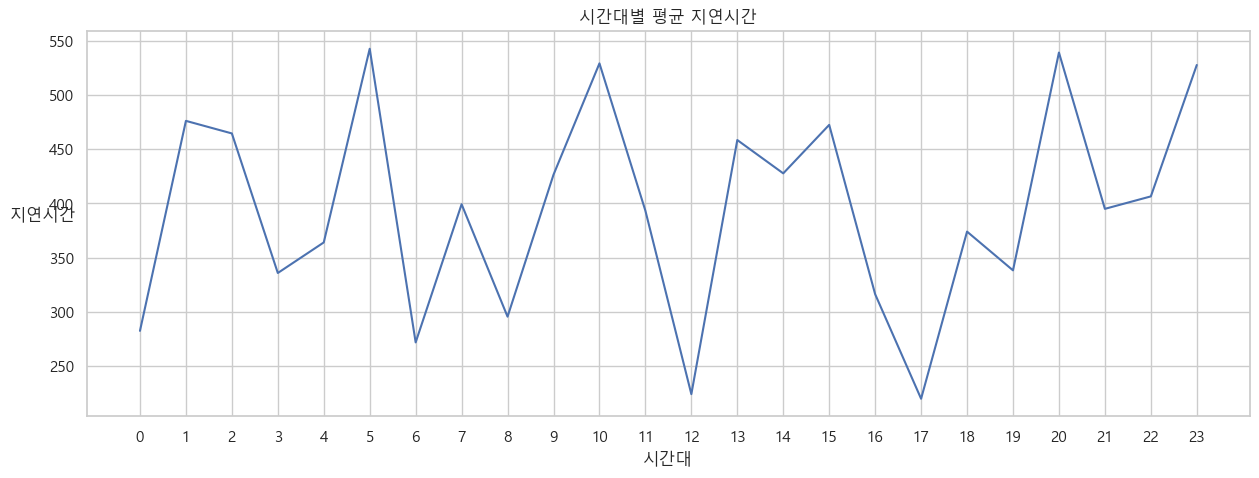

In [78]:
# Q
# 시간대별 평균 지연시간을 line plot 시각화 - 

# print( type(frm['timestamp']))
# hour = frm['timestamp'].dt.hour
# print(hour)

# frm.groupby(frm['timestamp'].dt.hour)['delay_ms'].mean().index
# frm.groupby(frm['timestamp'].dt.hour)['delay_ms'].mean().values


plt.figure( figsize = (15,5))

plt.plot(frm.groupby(frm['timestamp'].dt.hour)['delay_ms'].mean().index,
         frm.groupby(frm['timestamp'].dt.hour)['delay_ms'].mean().values)

plt.xticks(frm.groupby(frm['timestamp'].dt.hour)['delay_ms'].mean().index)

plt.title('시간대별 평균 지연시간')
plt.xlabel('시간대')
plt.ylabel('지연시간',rotation = 0)



plt.show()
plt.close()

In [79]:
irisFrm = sns.load_dataset('iris')
irisFrm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [80]:
irisFrm.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Figure size 640x480 with 0 Axes>

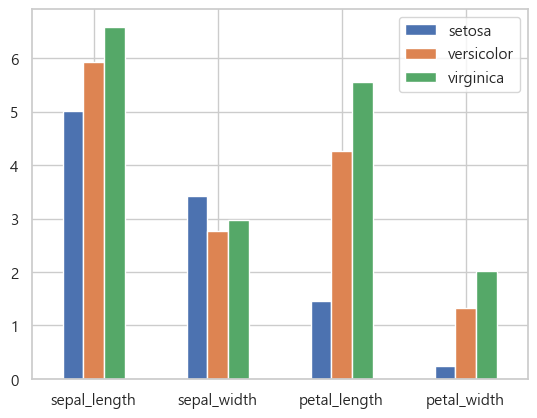

In [90]:
# Q
# 품종을 기준으로 그룹화 후 막대그래프로 시각화 
speciesFrm = irisFrm.groupby('species').mean()

plt.figure()

# speciesFrm.plot(kind='bar')
speciesFrm.T.plot(kind='bar')

plt.legend(loc = 'best')
plt.xticks(rotation=0)
plt.show()
plt.close()

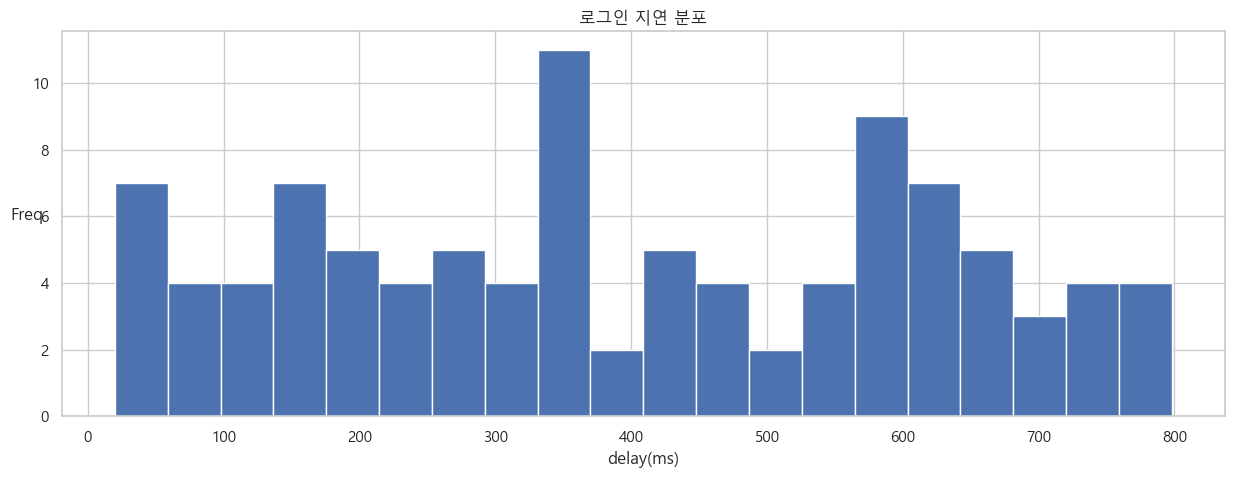

In [93]:
# histogram : 정규분포, 치우침 
# 연속형 데이터의 분포(distribution) , 일정한 구간(bin)
# 해당 구간에 포함되는 데이터의 개수를 세어서 막대형태로 표현 
# Q 로그인 지연 분포 확인 


plt.figure( figsize = (15,5))

plt.hist(frm['delay_ms'], bins=20)

plt.title('로그인 지연 분포')
plt.xlabel('delay(ms)')
plt.ylabel('Freq',rotation = 0)
plt.show()
plt.close()


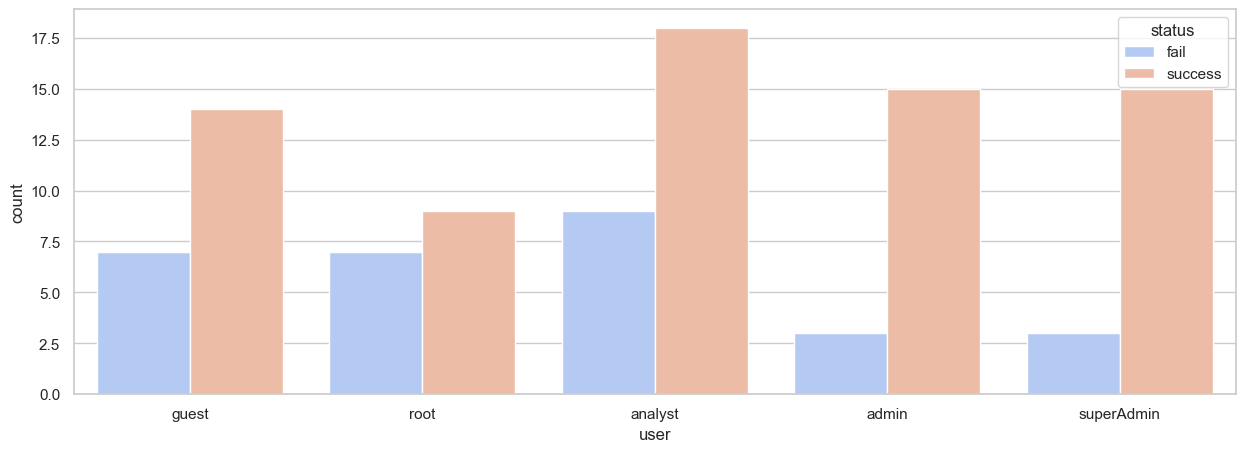

In [106]:
# countplot 
# 사용자별 로그인 시도 패턴 

plt.figure(figsize = (15, 5))

sns.countplot(x='user', hue='status', data=frm , palette='coolwarm')

plt.show()
plt.close()

In [107]:
# box plot : 이상치(outlier) 탐지를 위한 시각화 도구 
# 데이의 중심(median) , 퍼짐(사분위수), 이상치(outlier)를 한눈에 보여줌
# Q1(25%), Q2(50%), Q3(75%)
# IQR(Inner Quartile Range) : Q3 - Q1 
# lower bound = (Q1 - 1.5) * IQR , upper bound :  (Q3 + 1.5) * IQR 
# 판정기준 : 값 < lower bound : 하한 이상치 , 값 > upper bound : 상한 이상치 
# whisker(수염) : IQR 1.5배 범위 내 데이터  

In [111]:
boxFrm = pd.DataFrame({
    "user"      : np.random.choice(['admin', 'root', 'guest'], 100),
    "delay_ms"  : np.concatenate([
                    np.random.normal(200, 50, 80),
                    np.random.normal(800, 20, 10),
                    np.random.normal(100, 20, 10)
                  ])
})
boxFrm.head()

,user,delay_ms
0,guest,114.022950
1,guest,186.948637
2,guest,206.749236
3,admin,220.628520
4,root,103.515770


In [114]:
boxFrm['delay_ms'].describe()

count    100.000000
mean     242.099530
std      198.731176
min       25.959559
25%      145.705620
50%      183.427612
75%      239.711004
max      830.633776
Name: delay_ms, dtype: float64

In [121]:
# IQR
Q1 = boxFrm['delay_ms'].quantile(0.25) 
print('Q - ' , Q1)
Q3 = boxFrm['delay_ms'].quantile(0.75) 
print('Q - ' , Q3)
IQR = Q3 - Q1 
print('IQR - ', IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'lower {lower_bound} , upper {upper_bound}' )

Q -  145.70562023544753
Q -  239.7110041348567
IQR -  94.00538389940917
lower 4.69754438633376 , upper 380.71907998397046


In [123]:
print('이상치 탐지 - ') 
outliers = boxFrm[ (boxFrm['delay_ms'] < lower_bound) |  (boxFrm['delay_ms'] > upper_bound)]
print(outliers)

이상치 탐지 - 
     user    delay_ms
80  admin  806.111086
81   root  818.659933
82  guest  808.433698
83   root  808.112352
84  guest  814.300140
85  guest  810.048333
86   root  817.148919
87  guest  820.170416
88   root  830.633776
89  guest  787.016174


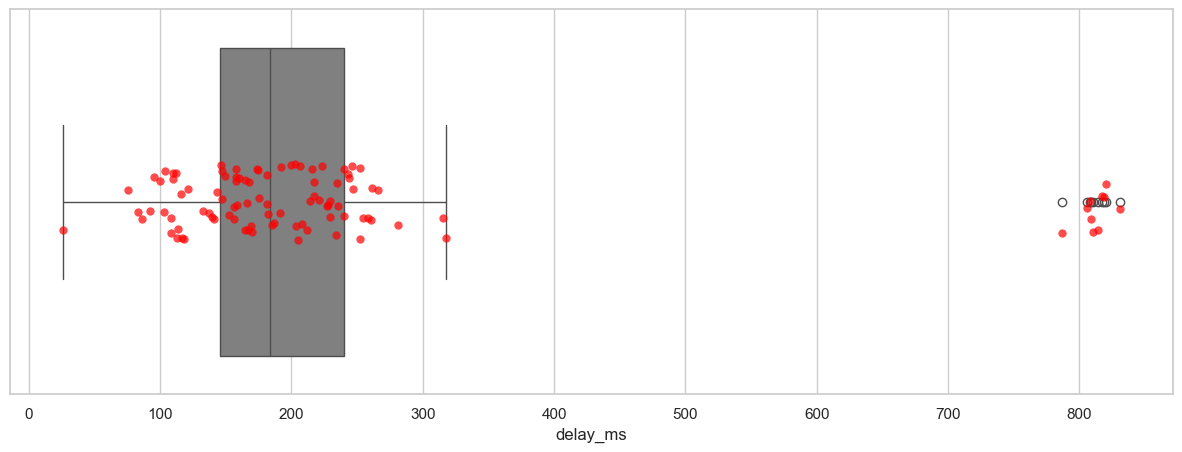

In [127]:
# box plot : 이상치(outlier) 탐지를 위한 시각화 도구 
# 로그인 지연시간 이상치 탐지 

plt.figure(figsize = (15, 5))

sns.boxplot(x='delay_ms' , data=boxFrm, color='gray' ) 
sns.stripplot(x='delay_ms' , data=boxFrm, color='red', size=6, jitter=True, alpha=0.7)
plt.show()
plt.close()

In [129]:
# 산점도(scatter plot) 
# 두 개의 연속형변수 간의 관계를 시각화 
# x : 독립변수(feature) , y : 종속변수(target) 
# 점들이 어떤 패턴(선형, 곡선, 군집)을 이루는지 보면서 변수간의 관계를 파악위한 시각화 

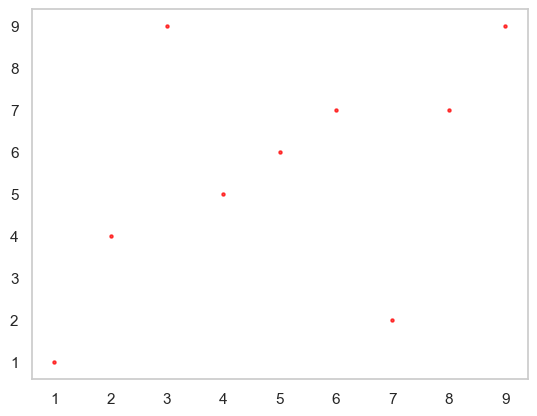

In [135]:
plt.figure()

x = [1,2,3,4,5,6,7,8,9]
y = [1,4,9,5,6,7,2,7,9]

plt.scatter(x,y, color='red', s=5, alpha=0.7, marker='o')

plt.grid(False)
plt.show()
plt.close()

In [136]:
# Q
# 사용자별 로그인 시도 패턴을 산점도로 시각화하고 싶다(시도횟수 )
# 각 점은 : 사용자 
# x : 평균 로그인 지연시간
# y : 실패율(failRatio) 

# insight : 비정상적인 사용자 행동 패턴을 탐지할 수 있다.

In [137]:
scatterFrm = pd.DataFrame({
    "timestamp" : pd.date_range('2025-11-06', periods=100, freq='H'),
    "user"      : np.random.choice(['admin', 'superAdmin', 'root', 'guest', 'analyst'], 100),
    "ip"        : np.random.choice(['192.168.0.1', '192.168.0.3', '192.168.0.5', '192.168.0.7', '192.168.0.9'], 100),
    "status"    : np.random.choice(['success', 'fail'], 100, p=[0.6, 0.4]),
    "delay_ms"  : np.random.randint(20, 800, 100)
})
scatterFrm.head()

,timestamp,user,ip,status,delay_ms
0,2025-11-06 00:00:00,analyst,192.168.0.3,success,330
1,2025-11-06 01:00:00,analyst,192.168.0.3,success,227
2,2025-11-06 02:00:00,analyst,192.168.0.1,fail,637
3,2025-11-06 03:00:00,admin,192.168.0.3,success,465
4,2025-11-06 04:00:00,guest,192.168.0.1,success,689


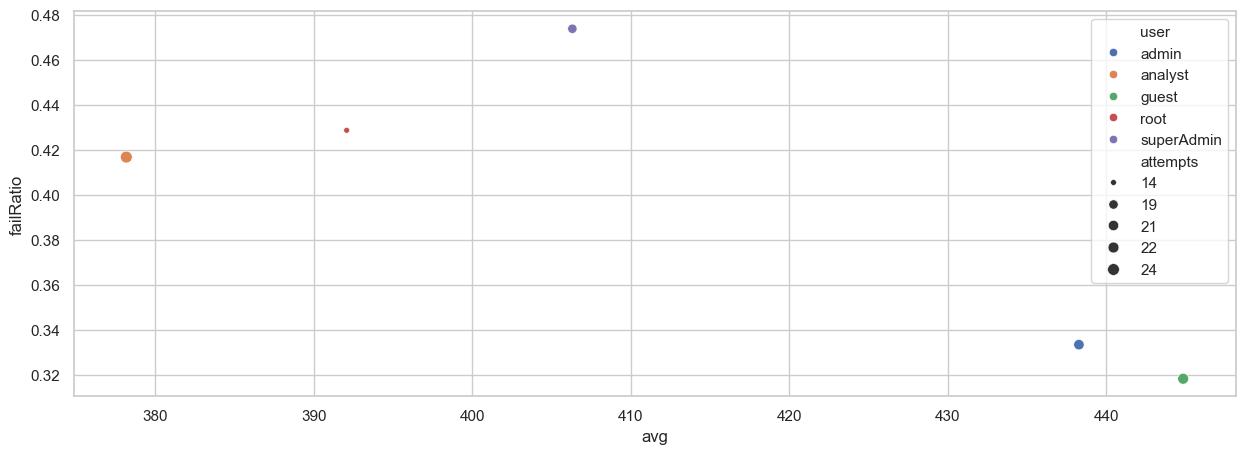

In [170]:
# 김민곤님...
# plt.figure()
# x = scatterFrm.groupby('user')['delay_ms'].mean()
# y = scatterFrm.groupby('user')['status'].apply(lambda x : x.value_counts()['fail']/x.value_counts().sum())
# plt.scatter(x, y, color='red', s=5, marker='o')
# plt.show()
# plt.close()

# teacher ....
avg = scatterFrm.groupby('user')['delay_ms'].mean()
# print(x)
failRatio = scatterFrm.groupby('user')['status'].apply(lambda x : (x=='fail').mean() ) 
# print(y)
attempts = scatterFrm['user'].value_counts()
# print(attempts)

userStatus = pd.DataFrame({
   'avg' : avg , 
   'failRatio' : failRatio,
   'attempts' : attempts 
});

plt.figure( figsize = (15, 5))

sns.scatterplot(x='avg', 
                y='failRatio', 
                data=userStatus , 
                size = 'attempts',
                hue='user')

plt.show()
plt.close()

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


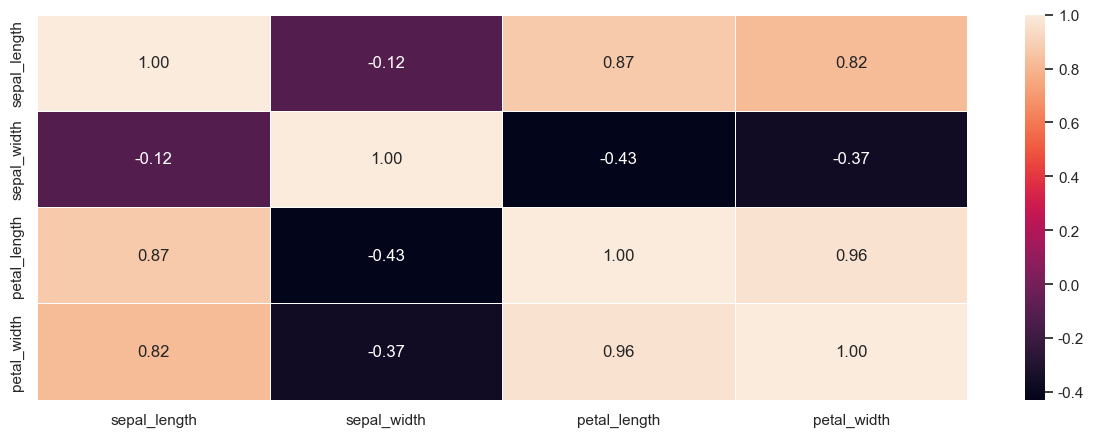

In [176]:
# heatmap
corr = irisFrm.corr(numeric_only= True)
print(corr)

plt.figure( figsize = (15, 5))

sns.heatmap(corr, fmt='.2f', annot=True, linewidth=0.5)

plt.show()
plt.close()


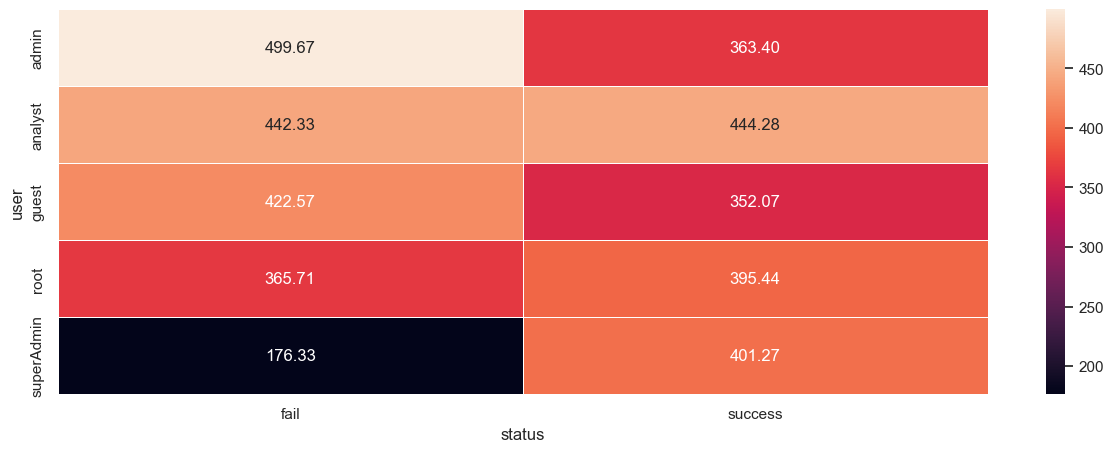

In [179]:
# frm 데이터를 이용해서 히트맵 시각화 
# Q
# 사용자-상태별 평균 지연시간 

pivot = frm.pivot_table(index='user' , columns='status', values='delay_ms', aggfunc='mean')
# print(pivot)
plt.figure( figsize = (15, 5))

sns.heatmap(pivot, fmt='.2f', annot=True, linewidth=0.5)

plt.show()
plt.close()

#### [Quiz]
- 피할 수 없다면 즐겨보자구요~~

In [ ]:
mpgFrm = pd.read_excel('./data/mpg_visualization.xlsx' , 
                       index_col = 0)
mpgFrm.head()

In [ ]:
# print('Q1) 배기량(displ)에 따른 고속연비를 확인하고 한다')
# print('배기량 4 이하인 자동차와 5이상인 자동차 중 고속도로 평균연비가 높은지를 확인한다면')

In [ ]:
# print('Q2) 자동차 제조사에 따른 도시 연비를 비교할려고 한다')
# print('audi , toyota 두 회사의 모든 차종에 대한 도시연비 평균을 비교 - ') 

In [ ]:
# print('Q3) chevrolet, ford, honda 제조사의 모든 차종에 대한 고속도로 연비 평균을 시각화')

In [ ]:
# print('Q4)구동방식별 고속도로연비평균을 막대 그래프로 시각화 - ')

In [180]:
# print('Q5) 구동방식별 고속도로, 도시연비 평균을 서브셋을 만들고')
# print('시각화 - multi bar ') 

In [ ]:
# print('Q6) 해당 클래스별 빈도수를 시각화 - ')